# Hub de análise — Banco Master OSINT

Notebook de exploração do `data/master.db`. Estruturado em seções independentes — pode rodar do começo ao fim ou pular para a parte de interesse.

Pré-requisitos: `data/master.db` populado (rodar `python pipeline.py`, `python -m grafo.b2b`, `python -m db`, `python -m coleta.cvm_diario` antes).

Estrutura:
1. Setup e visão geral
2. Pessoas — quem são, em quantas empresas
3. Linha do tempo de participações
4. Fundos e gestoras parceiras
5. Análise temporal dos 4 FMP-FGTS (séries diárias + marcos)
6. RandomForest Proximity — agrupamento de sócios sem rótulo
7. Conclusões e próximas iterações

## 1. Setup e visão geral

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from consultas import (
    resumo, ranking_pessoas, pessoas_em_n,
    participacoes_de, gestoras_top, custodiantes_top,
    inf_diario_fundo, primeiro_e_ultimo_dia, resgates_atipicos,
)

DB = Path('data/master.db')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
resumo()

,tabela,linhas
0,empresas,100
1,pessoas,104
2,participacoes,164
3,papeis_fundo,156
4,inf_diario,517


In [3]:
con = sqlite3.connect(DB)

empresas = pd.read_sql('SELECT * FROM empresas', con)
pessoas = pd.read_sql('SELECT * FROM pessoas', con)
participacoes = pd.read_sql('SELECT * FROM participacoes', con)
papeis_fundo = pd.read_sql('SELECT * FROM papeis_fundo', con)
inf_diario = pd.read_sql('SELECT * FROM inf_diario', con)
inf_diario['data'] = pd.to_datetime(inf_diario['data'])

print(f'empresas:        {len(empresas):>4}')
print(f'pessoas:         {len(pessoas):>4}')
print(f'participacoes:   {len(participacoes):>4}')
print(f'papeis_fundo:    {len(papeis_fundo):>4}')
print(f'inf_diario:      {len(inf_diario):>4}')
print(f'periodo inf_diario: {inf_diario["data"].min().date()} a {inf_diario["data"].max().date()}')

empresas:         100
pessoas:          104
participacoes:    164
papeis_fundo:     156
inf_diario:       517
periodo inf_diario: 2025-01-02 a 2025-11-12


## 2. Pessoas — quem aparece, em quantas empresas

O grupo Master tem 19 pessoas físicas no QSA das 7 entidades. Duas delas (Angelo Antonio e Luiz Bull) aparecem em mais empresas do que o próprio Vorcaro.

In [4]:
ranking = ranking_pessoas(20)
ranking

,nome,n_empresas,qualificacoes
0,ALEXANDRE JORGE CHAIA,4,Administrador | Administrador | Sócio-Administrador | Sócio-Administrador
1,ANGELO ANTONIO RIBEIRO DA SILVA,4,Diretor | Diretor | Diretor | Diretor
2,GUSTAVO AUGUSTO VASCONCELOS BIAVA,4,Sócio-Administrador | Administrador | Administrador | Sócio-Administrador
3,JOSE ROBERTO GIANCOLI FILHO,4,Sócio-Administrador | Administrador | Administrador | Sócio-Administrador
4,LUIZ ANTONIO BULL,4,Diretor | Presidente | Diretor | Diretor
5,ADEMIR SILVA OLIVEIRA,3,Administrador | Sócio-Administrador | Sócio-Administrador
6,DANIEL BUENO VORCARO,3,Presidente | Presidente | Sócio
7,GUARACI SILLOS MOREIRA,3,Administrador | Sócio | Sócio-Administrador
8,MAURICIO ANTONIO QUADRADO,3,Presidente | Sócio | Diretor
9,RENATA FERRAZ DE ANDRADE DE ALMEIDA SOUZA,3,Administrador | Administrador | Sócio-Administrador


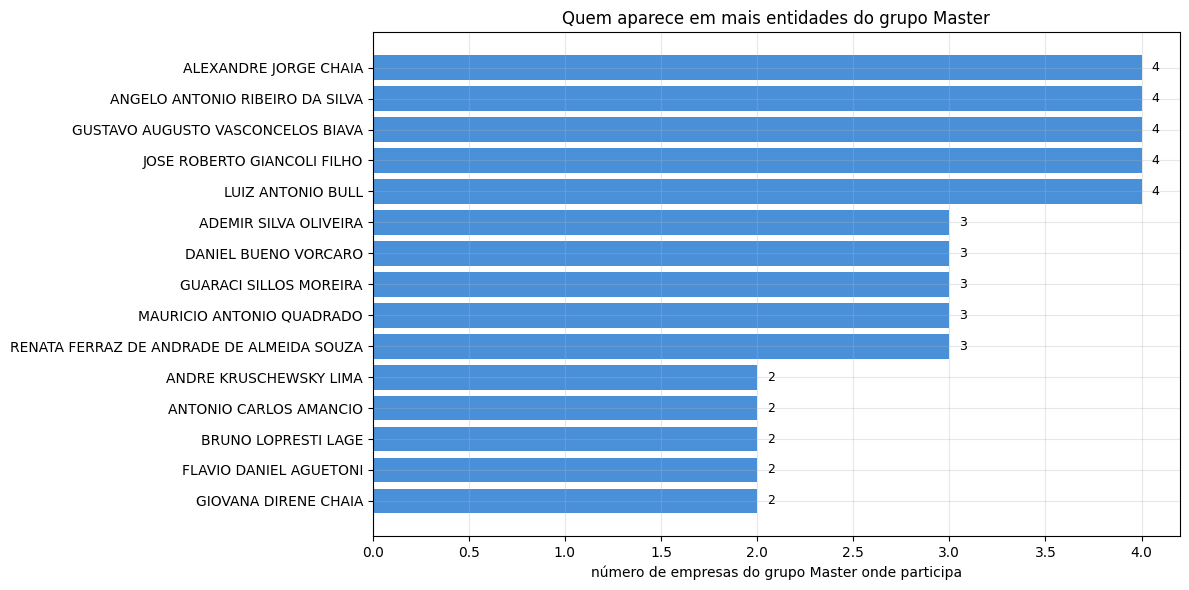

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
top = ranking.head(15).iloc[::-1]
bars = ax.barh(top['nome'], top['n_empresas'], color='#4A90D9')
for bar, valor in zip(bars, top['n_empresas']):
    ax.text(valor + 0.05, bar.get_y() + bar.get_height()/2, str(valor),
            va='center', fontsize=9)
ax.set_xlabel('número de empresas do grupo Master onde participa')
ax.set_title('Quem aparece em mais entidades do grupo Master')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Linha do tempo das participações

Visualizar quando cada sócio entrou em cada entidade revela densidade de movimentos no QSA — especialmente nos 12 meses anteriores à liquidação BACEN.

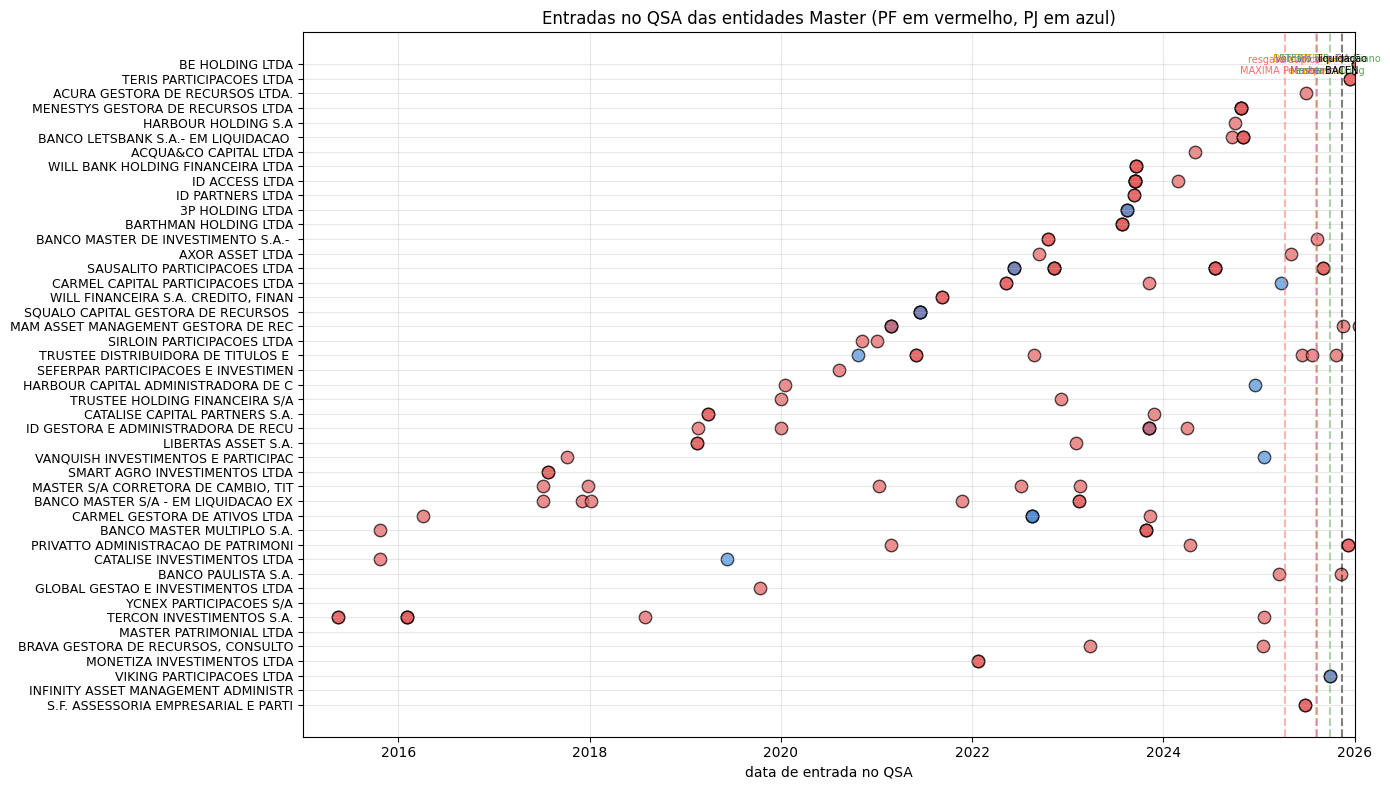

In [6]:
timeline = pd.read_sql('''
    SELECT p.data_entrada, e.razao_social,
           COALESCE(s.nome, soc.razao_social) AS socio,
           CASE WHEN p.socio_pessoa_id > 0 THEN 'PF' ELSE 'PJ' END AS tipo,
           p.qualificacao
    FROM participacoes p
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
    LEFT JOIN pessoas s ON s.id = p.socio_pessoa_id
    LEFT JOIN empresas soc ON soc.cnpj = p.socio_empresa_cnpj
    WHERE p.data_entrada != ''
    ORDER BY p.data_entrada
''', con)
timeline['data_entrada'] = pd.to_datetime(timeline['data_entrada'])
timeline['razao_curta'] = timeline['razao_social'].str[:35]

fig, ax = plt.subplots(figsize=(14, 8))
empresas_unicas = timeline['razao_curta'].unique()
y_map = {e: i for i, e in enumerate(empresas_unicas)}
cores_tipo = {'PF': '#E85D5D', 'PJ': '#4A90D9'}

for _, row in timeline.iterrows():
    ax.scatter(row['data_entrada'], y_map[row['razao_curta']],
               color=cores_tipo[row['tipo']], s=80, alpha=0.7, edgecolors='black')

for data, label, color in [
    ('2025-04-10', 'resgate atípico\nMAXIMA Petrobras', '#FF6B6B'),
    ('2025-08-06', 'BANESTES param\nde reportar',       '#FFA500'),
    ('2025-08-12', 'Vorcaro vira Pres.\nMaster Inv.',   '#9B59B6'),
    ('2025-09-29', 'STERN FIP + Adriano\nentram Viking', '#5BA85A'),
    ('2025-11-15', 'liquidação\nBACEN',                 '#000000'),
]:
    ax.axvline(pd.Timestamp(data), color=color, linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(data), len(empresas_unicas) - 0.3, label,
            rotation=0, fontsize=7, color=color, ha='center', va='top')

ax.set_yticks(range(len(empresas_unicas)))
ax.set_yticklabels(empresas_unicas, fontsize=9)
ax.set_xlabel('data de entrada no QSA')
ax.set_title('Entradas no QSA das entidades Master (PF em vermelho, PJ em azul)')
ax.set_xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2026-01-01'))
plt.tight_layout()
plt.show()

In [7]:
timeline_2024_2025 = timeline[timeline['data_entrada'] >= '2024-01-01'].sort_values('data_entrada')
print('Movimentos no QSA em 2024-2025:')
print(timeline_2024_2025[['data_entrada', 'socio', 'tipo', 'qualificacao', 'razao_curta']].to_string(index=False))

Movimentos no QSA em 2024-2025:
data_entrada                                                        socio tipo        qualificacao                         razao_curta
  2024-02-26                                    VINICIUS GONCALVES GARCIA   PF               Sócio                      ID ACCESS LTDA
  2024-04-02                                      NILEIDE GUERRA DE ABREU   PF       Administrador ID GESTORA E ADMINISTRADORA DE RECU
  2024-04-12                                      VANESSA SCALANTE JOHANN   PF               Sócio PRIVATTO ADMINISTRACAO DE PATRIMONI
  2024-05-01                    RENATA FERRAZ DE ANDRADE DE ALMEIDA SOUZA   PF Sócio-Administrador               ACQUA&CO CAPITAL LTDA
  2024-07-16                                  CINTIA SILVA OLIVEIRA COSTA   PF               Sócio        SAUSALITO PARTICIPACOES LTDA
  2024-07-16                                       GUARACI SILLOS MOREIRA   PF Sócio-Administrador        SAUSALITO PARTICIPACOES LTDA
  2024-07-16           

## 4. Fundos e gestoras parceiras

Dos 57 fundos com vínculo Master, a Master S/A Corretora é administradora de todos. A gestão é pulverizada em ~19 gestoras independentes.

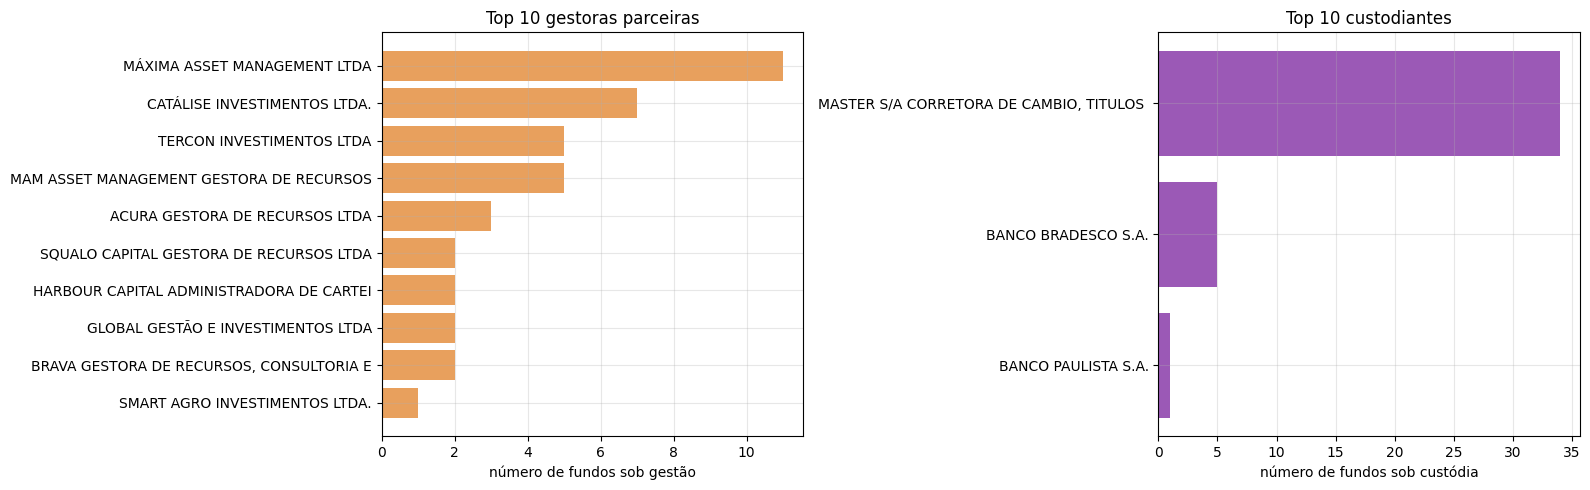

In [8]:
g_top = gestoras_top(10)
c_top = custodiantes_top(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(g_top['gestora'].str[:40].iloc[::-1], g_top['n_fundos'].iloc[::-1], color='#E8A05D')
axes[0].set_title('Top 10 gestoras parceiras')
axes[0].set_xlabel('número de fundos sob gestão')
axes[1].barh(c_top['custodiante'].str[:40].iloc[::-1], c_top['n_fundos'].iloc[::-1], color='#9B59B6')
axes[1].set_title('Top 10 custodiantes')
axes[1].set_xlabel('número de fundos sob custódia')
plt.tight_layout()
plt.show()

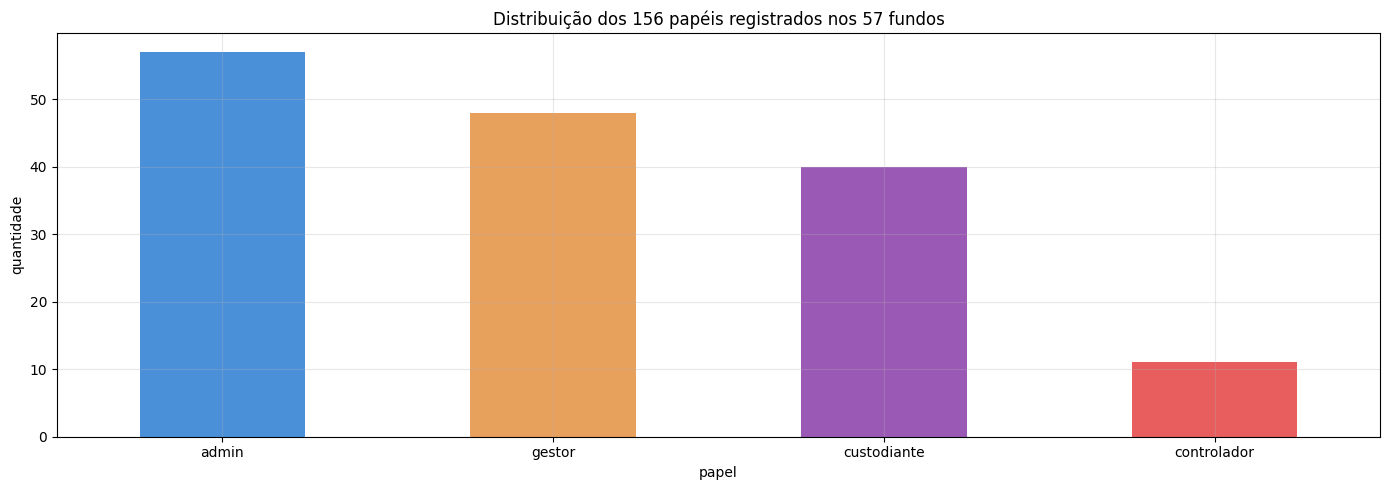

In [9]:
papeis_por_tipo = papeis_fundo.groupby('papel').size().sort_values(ascending=False)
papeis_por_tipo.plot(kind='bar', color=['#4A90D9', '#E8A05D', '#9B59B6', '#E85D5D'])
plt.title('Distribuição dos 156 papéis registrados nos 57 fundos')
plt.ylabel('quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Análise temporal dos 4 FMP-FGTS

Caso-âncora: 4 fundos de privatização lastreados em FGTS de trabalhadores. Cronologia esperada:
- abr/2025: resgate atípico R$ 254K no MAXIMA Petrobras
- ago/2025: BANESTES param de reportar
- ago/2025: Vorcaro vira Presidente do Master Investimento
- set/2025: STERN FIP entra na Viking
- nov/2025: liquidação BACEN

In [10]:
FMPS = {
    '02727085000130': 'MAXIMA FMP-FGTS PETROBRAS',
    '03919474000120': 'BANESTES FMP-FGTS PETROBRAS',
    '04894428000186': 'BANESTES FMP-FGTS VALE DO RIO DOCE',
    '04894438000111': 'MAXIMA FMP-FGTS VALE DO RIO DOCE',
}

MARCOS = [
    ('2025-04-10', 'resgate R$254K',  '#FF6B6B'),
    ('2025-08-06', 'BANESTES param',  '#FFA500'),
    ('2025-08-12', 'Vorcaro Pres MI', '#9B59B6'),
    ('2025-09-29', 'STERN entra',     '#5BA85A'),
    ('2025-11-15', 'liquid. BACEN',   '#000000'),
]

primeiro_e_ultimo_dia()

,fundo_cnpj,fundo,primeiro_dia,ultimo_dia,dias_reportados,pl_medio,cot_medio
0,02727085000130,MÁXIMA FMP - FGTS PETROBRAS,2025-01-02,2025-11-12,219,1580741.58,18.0
1,03919474000120,BANESTES FMP - FGTS PETROBRAS,2025-01-02,2025-08-06,149,107315.12,3.0
2,04894428000186,BANESTES FMP-FGTS VALE DO RIO DOCE,2025-01-02,2025-08-06,149,616922.92,21.0


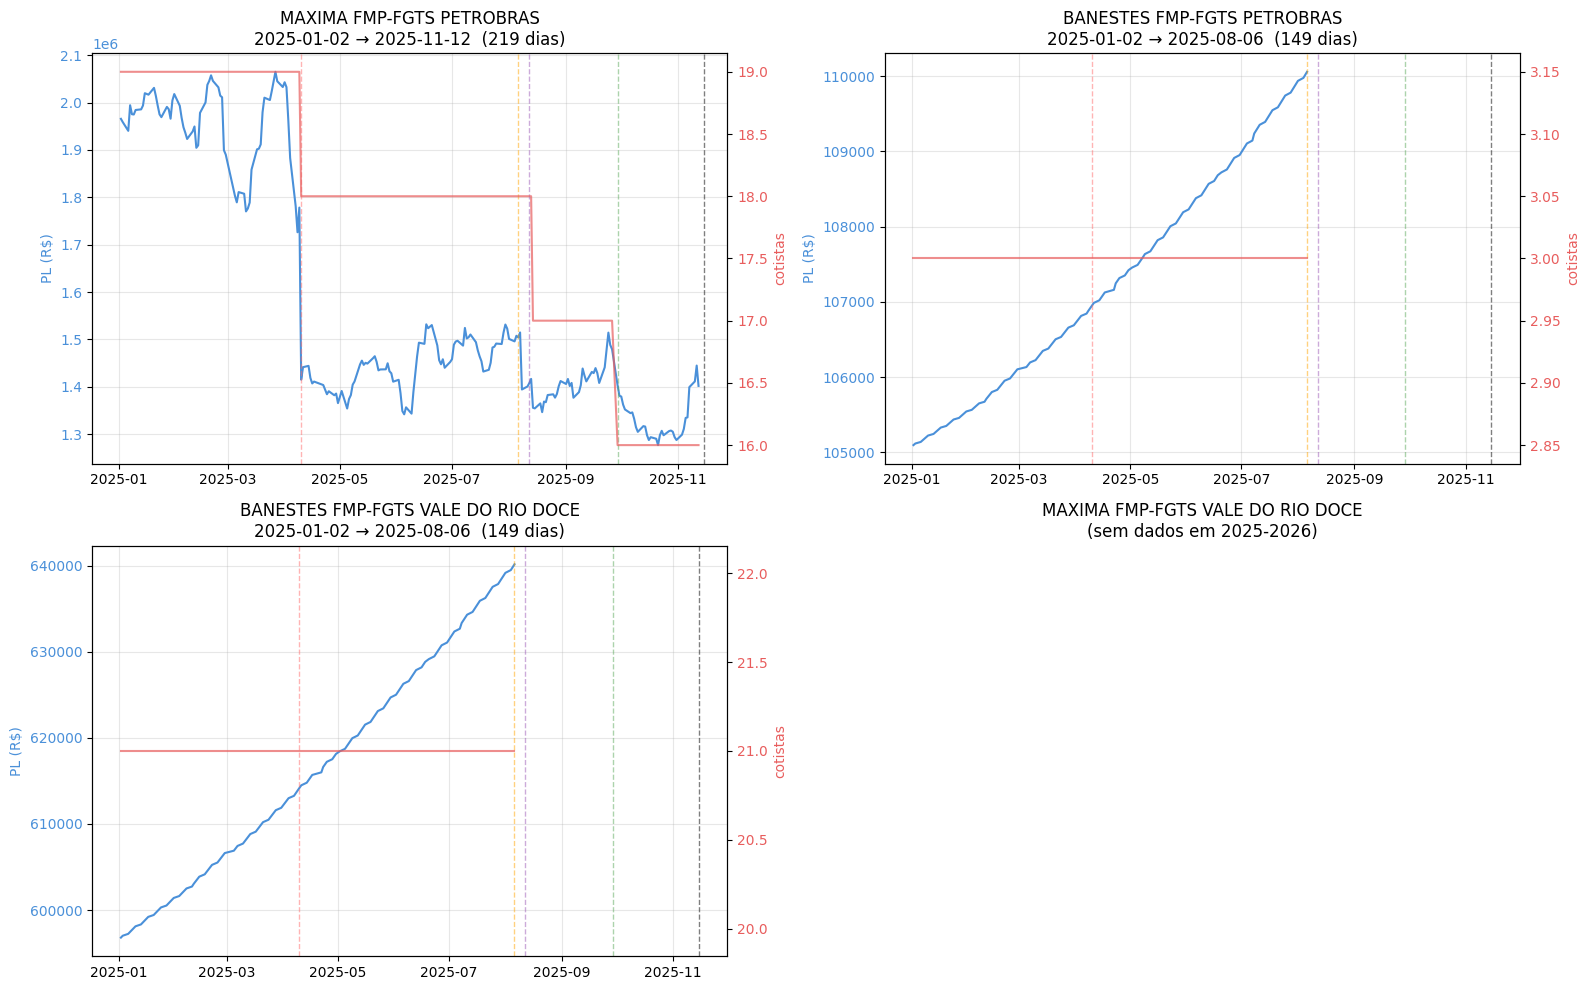

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for ax, (cnpj, nome) in zip(axes_flat, FMPS.items()):
    df = inf_diario[inf_diario['fundo_cnpj'] == cnpj].sort_values('data')
    if df.empty:
        ax.set_title(f'{nome}\n(sem dados em 2025-2026)')
        ax.axis('off')
        continue

    color_pl = '#4A90D9'
    ax.plot(df['data'], df['pl'], color=color_pl, label='PL (R$)', linewidth=1.5)
    ax.set_ylabel('PL (R$)', color=color_pl)
    ax.tick_params(axis='y', labelcolor=color_pl)

    ax2 = ax.twinx()
    color_cot = '#E85D5D'
    ax2.plot(df['data'], df['cotistas'], color=color_cot, label='cotistas', linewidth=1.5, alpha=0.7)
    ax2.set_ylabel('cotistas', color=color_cot)
    ax2.tick_params(axis='y', labelcolor=color_cot)
    ax2.grid(False)

    for data, label, color in MARCOS:
        d = pd.Timestamp(data)
        if df['data'].min() <= d <= pd.Timestamp('2026-04-30'):
            ax.axvline(d, color=color, linestyle='--', alpha=0.5, linewidth=1)

    ax.set_title(f'{nome[:50]}\n{df["data"].min().date()} → {df["data"].max().date()}  ({len(df)} dias)')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

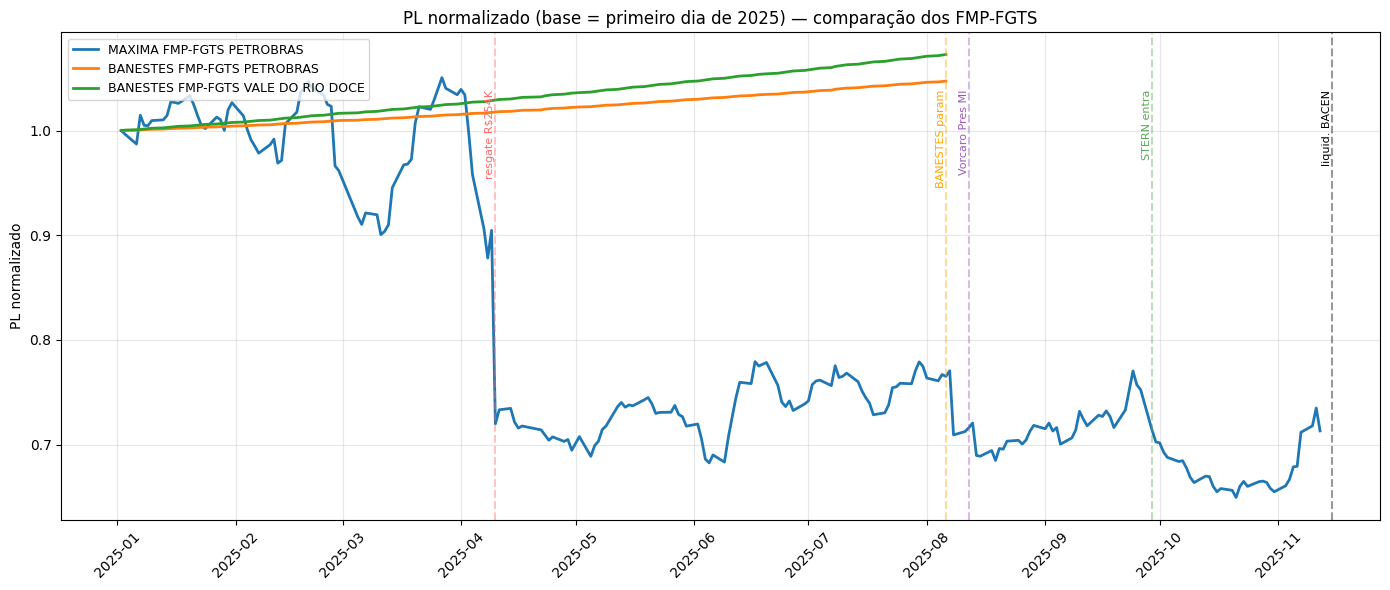

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
for cnpj, nome in FMPS.items():
    df = inf_diario[inf_diario['fundo_cnpj'] == cnpj].sort_values('data')
    if df.empty:
        continue
    pl_normalizado = df['pl'] / df['pl'].iloc[0]
    ax.plot(df['data'], pl_normalizado, label=nome[:35], linewidth=2)

for data, label, color in MARCOS:
    ax.axvline(pd.Timestamp(data), color=color, linestyle='--', alpha=0.4)
    ax.text(pd.Timestamp(data), ax.get_ylim()[1] * 0.95, label,
            rotation=90, fontsize=8, color=color, va='top', ha='right')

ax.set_title('PL normalizado (base = primeiro dia de 2025) — comparação dos FMP-FGTS')
ax.set_ylabel('PL normalizado')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
print('Resgates atípicos (>= R$ 50 mil em um único dia):')
resgates_atipicos(50_000)

Resgates atípicos (>= R$ 50 mil em um único dia):


,fundo_cnpj,fundo,data,resgate_dia,cotistas,pl
0,02727085000130,MÁXIMA FMP - FGTS PETROBRAS,2025-04-10,254334.89,18,1415009.18


## 6. RandomForest Proximity — agrupamento não-supervisionado de sócios

Pergunta: quais sócios são *funcionalmente próximos* dentro do grupo Master? Não basta dizer "quantas empresas em comum" — queremos uma métrica de proximidade que combine múltiplas dimensões.

**Método: Random Forest Proximity (Breiman).**
1. Constrói matriz de features pessoa × (entidades do grupo + qualificações + ano de entrada).
2. Gera dataset sintético permutando cada coluna independentemente (mantém marginais, destrói co-ocorrência).
3. Treina Random Forest pra distinguir "real" de "sintético".
4. Para cada par de pessoas reais, conta em quantas árvores eles caem na mesma folha. Normaliza por número de árvores.
5. Resultado: matriz [0, 1] onde valores altos = sócios que o modelo viu como funcionalmente similares.

Limitação: 19 pessoas é amostra pequena. O método dá resultado, mas qualquer afirmação estatística precisa ressalva.

In [14]:
qsa = pd.read_sql('''
    SELECT s.nome, e.razao_social, p.qualificacao, p.data_entrada, s.faixa_etaria
    FROM participacoes p
    JOIN pessoas s ON s.id = p.socio_pessoa_id
    JOIN empresas e ON e.cnpj = p.empresa_cnpj
''', con)
qsa['data_entrada'] = pd.to_datetime(qsa['data_entrada'], errors='coerce')
qsa['ano_entrada'] = qsa['data_entrada'].dt.year

incidencia = pd.crosstab(qsa['nome'], qsa['razao_social']).clip(upper=1)
incidencia.columns = ['emp:' + c[:25] for c in incidencia.columns]

qualif = pd.crosstab(qsa['nome'], qsa['qualificacao']).clip(upper=1)
qualif.columns = ['qual:' + c for c in qualif.columns]

stats = qsa.groupby('nome').agg(
    n_empresas=('razao_social', 'nunique'),
    ano_min=('ano_entrada', 'min'),
    ano_max=('ano_entrada', 'max'),
)
stats['ano_min'] = stats['ano_min'].fillna(2000)
stats['ano_max'] = stats['ano_max'].fillna(2000)
stats['span_anos'] = stats['ano_max'] - stats['ano_min']

X = incidencia.join(qualif).join(stats)
X.index.name = 'nome'
print(f'Matriz de features: {X.shape[0]} pessoas × {X.shape[1]} features')
X.head()

Matriz de features: 104 pessoas × 55 features


,emp:3P HOLDING LTDA,emp:ACQUA&CO CAPITAL LTDA,emp:ACURA GESTORA DE RECURSOS,emp:AXOR ASSET LTDA,emp:BANCO LETSBANK S.A.- EM L,emp:BANCO MASTER DE INVESTIME,emp:BANCO MASTER MULTIPLO S.A,emp:BANCO MASTER S/A - EM LIQ,emp:BANCO PAULISTA S.A.,emp:BARTHMAN HOLDING LTDA,emp:BE HOLDING LTDA,emp:BRAVA GESTORA DE RECURSOS,emp:CARMEL CAPITAL PARTICIPAC,emp:CARMEL GESTORA DE ATIVOS,emp:CATALISE CAPITAL PARTNERS,emp:CATALISE INVESTIMENTOS LT,emp:GLOBAL GESTAO E INVESTIME,emp:HARBOUR CAPITAL ADMINISTR,emp:HARBOUR HOLDING S.A,emp:ID ACCESS LTDA,emp:ID GESTORA E ADMINISTRADO,emp:ID PARTNERS LTDA,emp:INFINITY ASSET MANAGEMENT,emp:LIBERTAS ASSET S.A.,emp:MAM ASSET MANAGEMENT GEST,emp:MASTER PATRIMONIAL LTDA,emp:MASTER S/A CORRETORA DE C,emp:MENESTYS GESTORA DE RECUR,emp:MONETIZA INVESTIMENTOS LT,emp:PRIVATTO ADMINISTRACAO DE,emp:S.F. ASSESSORIA EMPRESARI,emp:SAUSALITO PARTICIPACOES L,emp:SEFERPAR PARTICIPACOES E,emp:SIRLOIN PARTICIPACOES LTD,emp:SMART AGRO INVESTIMENTOS,emp:SQUALO CAPITAL GESTORA DE,emp:TERCON INVESTIMENTOS S.A.,emp:TERIS PARTICIPACOES LTDA,emp:TRUSTEE DISTRIBUIDORA DE,emp:TRUSTEE HOLDING FINANCEIR,emp:VANQUISH INVESTIMENTOS E,emp:VIKING PARTICIPACOES LTDA,emp:WILL BANK HOLDING FINANCE,emp:WILL FINANCEIRA S.A. CRED,emp:YCNEX PARTICIPACOES S/A,qual:Administrador,qual:Conselheiro de Administração,qual:Diretor,qual:Presidente,qual:Sócio,qual:Sócio-Administrador,n_empresas,ano_min,ano_max,span_anos
nome,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ADEMIR SILVA OLIVEIRA,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,3,2016,2022,6
ADRIANA DIRENE CHAIA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1997,1997,0
ADRIANO GARZON CORREA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2025,2025,0
ALAN RIGONI DE ALMEIDA SOUZA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,2021,2021,0
ALEXANDRE JORGE CHAIA,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,4,1997,2022,25


In [15]:
from sklearn.ensemble import RandomForestClassifier

def rf_proximity(X_df, n_estimators=500, random_state=42):
    rng = np.random.default_rng(random_state)
    X = X_df.values.astype(float)
    n, p = X.shape

    X_syn = np.column_stack([rng.permutation(X[:, j]) for j in range(p)])
    X_combined = np.vstack([X, X_syn])
    y_combined = np.concatenate([np.ones(n), np.zeros(n)])

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1,
        min_samples_leaf=1,
    )
    rf.fit(X_combined, y_combined)

    leaves = rf.apply(X)
    prox = np.zeros((n, n))
    for t in range(n_estimators):
        leaves_t = leaves[:, t]
        same = leaves_t[:, None] == leaves_t[None, :]
        prox += same.astype(float)
    prox /= n_estimators

    return pd.DataFrame(prox, index=X_df.index, columns=X_df.index), rf

prox_df, rf_model = rf_proximity(X, n_estimators=500)
print(f'RF AUC real-vs-sintetico (treino):  {rf_model.score(np.vstack([X.values, np.column_stack([np.random.default_rng(42).permutation(X.values[:, j]) for j in range(X.shape[1])])]), np.concatenate([np.ones(len(X)), np.zeros(len(X))])):.3f}')
print(f'Matriz de proximidade: {prox_df.shape}')

RF AUC real-vs-sintetico (treino):  0.500
Matriz de proximidade: (104, 104)


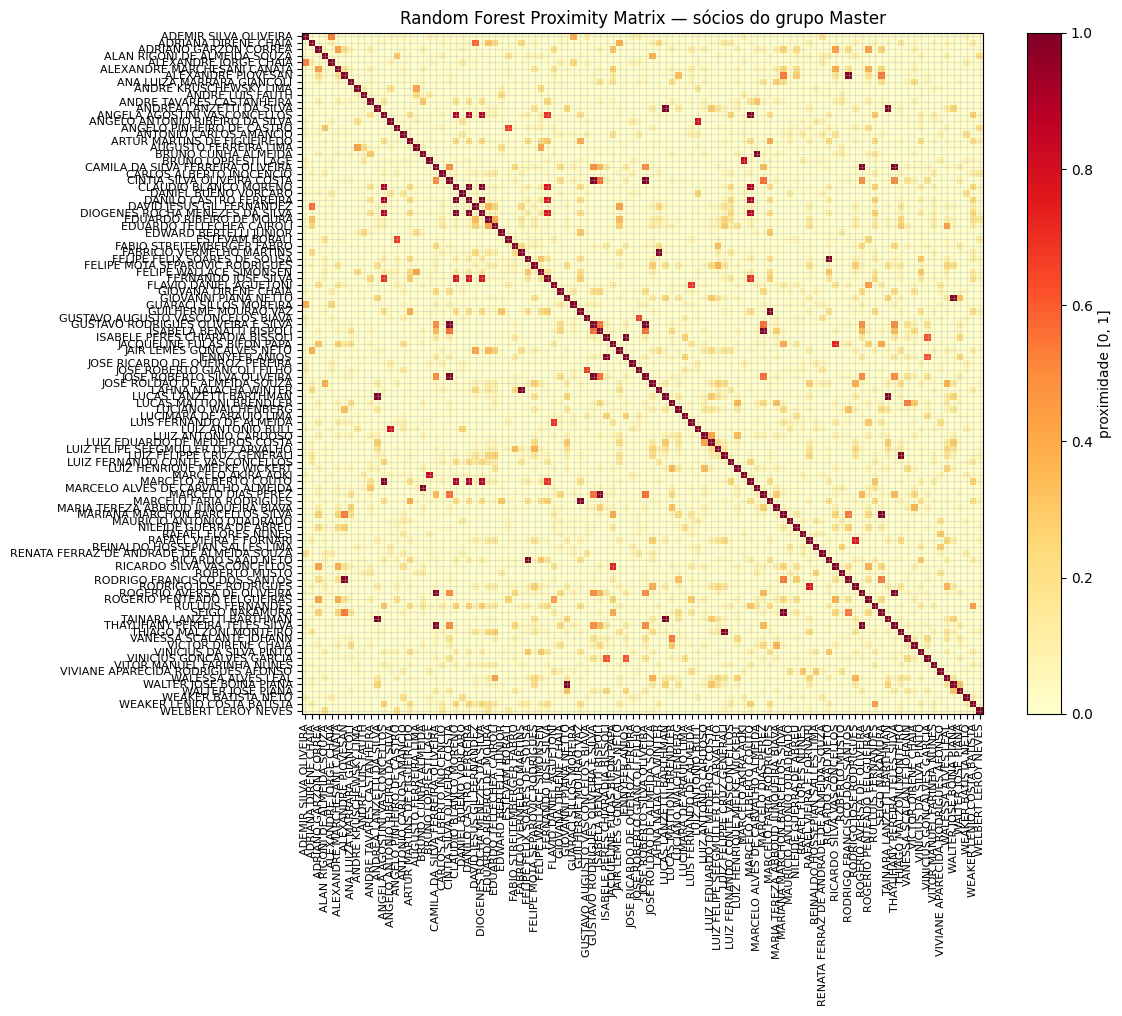

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(prox_df.values, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(prox_df))); ax.set_xticklabels(prox_df.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(prox_df))); ax.set_yticklabels(prox_df.index, fontsize=8)
ax.set_title('Random Forest Proximity Matrix — sócios do grupo Master')
plt.colorbar(im, ax=ax, label='proximidade [0, 1]')
plt.tight_layout()
plt.show()

In [17]:
pares = []
nomes = list(prox_df.index)
for i, a in enumerate(nomes):
    for b in nomes[i+1:]:
        pares.append((a, b, prox_df.loc[a, b]))

pares_df = pd.DataFrame(pares, columns=['socio_a', 'socio_b', 'proximidade']).sort_values('proximidade', ascending=False)
print('Top 15 pares de sócios pelo Random Forest Proximity:')
pares_df.head(15)

Top 15 pares de sócios pelo Random Forest Proximity:


,socio_a,socio_b,proximidade
3398,GIOVANNI PIANA NETTO,WALTER JOSE BOINA PIANA,1.0
2986,FELIPE FELIX SOARES DE SOUSA,RICARDO SAAD NETO,1.0
3493,GUILHERME MOURAO VAZ,MARCELO FARIA RODRIGUES,1.0
1121,ANDREA LANZETTI DA SILVA,LUCAS LANZETTI BARTHMAN,1.0
1155,ANDREA LANZETTI DA SILVA,TAINARA LANZETTI BARTHMAN,1.0
3705,ISABELE PERES CHIARADIA BISSOLI,JENNYFER ANJOS,1.0
3593,GUSTAVO RODRIGUES OLIVEIRA E SILVA,JOSE ROBERTO SILVA OLIVEIRA,1.0
2276,DANILO CASTRO FERREIRA,DIOGENES ROCHA MENEZES DA SILVA,1.0
1225,ANGELA AGOSTINI VASCONCELLOS,MARCELO ALBERTO COUTO,1.0
679,ALEXANDRE PIOVESAN,RODRIGO FRANCISCO DOS SANTOS,1.0


In [18]:
from scipy.spatial.distance import pdist, squareform

jacc_dist = pdist(incidencia.values, metric='jaccard')
jacc_sim = (1 - squareform(jacc_dist)).copy()
np.fill_diagonal(jacc_sim, 0)
jacc_df = pd.DataFrame(jacc_sim, index=incidencia.index, columns=incidencia.index)

pares_jacc = []
for i, a in enumerate(nomes):
    for b in nomes[i+1:]:
        pares_jacc.append((a, b, jacc_df.loc[a, b]))
pares_jacc_df = pd.DataFrame(pares_jacc, columns=['socio_a', 'socio_b', 'jaccard']).sort_values('jaccard', ascending=False)

comparativo = pares_df.merge(pares_jacc_df, on=['socio_a', 'socio_b'])
comparativo['rank_rf']      = comparativo['proximidade'].rank(ascending=False).astype(int)
comparativo['rank_jaccard'] = comparativo['jaccard'].rank(ascending=False).astype(int)
comparativo['discordancia'] = (comparativo['rank_rf'] - comparativo['rank_jaccard']).abs()

print('Comparativo RF vs Jaccard - top 15 por RF:')
comparativo.sort_values('proximidade', ascending=False).head(15)

Comparativo RF vs Jaccard - top 15 por RF:


,socio_a,socio_b,proximidade,jaccard,rank_rf,rank_jaccard,discordancia
0,GIOVANNI PIANA NETTO,WALTER JOSE BOINA PIANA,1.0,1.0,12,58,46
1,FELIPE FELIX SOARES DE SOUSA,RICARDO SAAD NETO,1.0,1.0,12,58,46
2,GUILHERME MOURAO VAZ,MARCELO FARIA RODRIGUES,1.0,1.0,12,58,46
3,ANDREA LANZETTI DA SILVA,LUCAS LANZETTI BARTHMAN,1.0,1.0,12,58,46
4,ANDREA LANZETTI DA SILVA,TAINARA LANZETTI BARTHMAN,1.0,1.0,12,58,46
5,ISABELE PERES CHIARADIA BISSOLI,JENNYFER ANJOS,1.0,1.0,12,58,46
6,GUSTAVO RODRIGUES OLIVEIRA E SILVA,JOSE ROBERTO SILVA OLIVEIRA,1.0,1.0,12,58,46
7,DANILO CASTRO FERREIRA,DIOGENES ROCHA MENEZES DA SILVA,1.0,1.0,12,58,46
8,ANGELA AGOSTINI VASCONCELLOS,MARCELO ALBERTO COUTO,1.0,1.0,12,58,46
9,ALEXANDRE PIOVESAN,RODRIGO FRANCISCO DOS SANTOS,1.0,1.0,12,58,46


In [19]:
print('Pares onde RF e Jaccard mais discordam (sinal de informação no RF além da simples co-ocorrência):')
comparativo.sort_values('discordancia', ascending=False).head(10)

Pares onde RF e Jaccard mais discordam (sinal de informação no RF além da simples co-ocorrência):


,socio_a,socio_b,proximidade,jaccard,rank_rf,rank_jaccard,discordancia
43,ADRIANA DIRENE CHAIA,DAVID JESUS GIL FERNANDEZ,0.580,0.0,44,2792,2748
66,RUI LUIS FERNANDES,WEAKER LENIO COSTA BATISTA,0.446,0.0,67,2792,2725
67,ADRIANO GARZON CORREA,ALEXANDRE MARCHESANI CANATA,0.440,0.0,68,2792,2724
69,ADRIANO GARZON CORREA,RICARDO SILVA VASCONCELLOS,0.434,0.0,70,2792,2722
71,ADRIANO GARZON CORREA,ROGERIO PENTEADO FELGUEIRAS,0.424,0.0,72,2792,2720
72,DAVID JESUS GIL FERNANDEZ,JAIR LEMES GONCALVES NETO,0.424,0.0,72,2792,2720
75,ARTUR MARTINS DE FIGUEIREDO,MARCELO FARIA RODRIGUES,0.406,0.0,76,2792,2716
76,ARTUR MARTINS DE FIGUEIREDO,GUILHERME MOURAO VAZ,0.406,0.0,76,2792,2716
77,JACQUELINE FULAS BIFON PAPA,SEIGO NAKAMURA,0.400,0.0,78,2792,2714
78,JACQUELINE FULAS BIFON PAPA,MARIANA MARCHON BARCELLOS SILVA,0.400,0.0,78,2792,2714


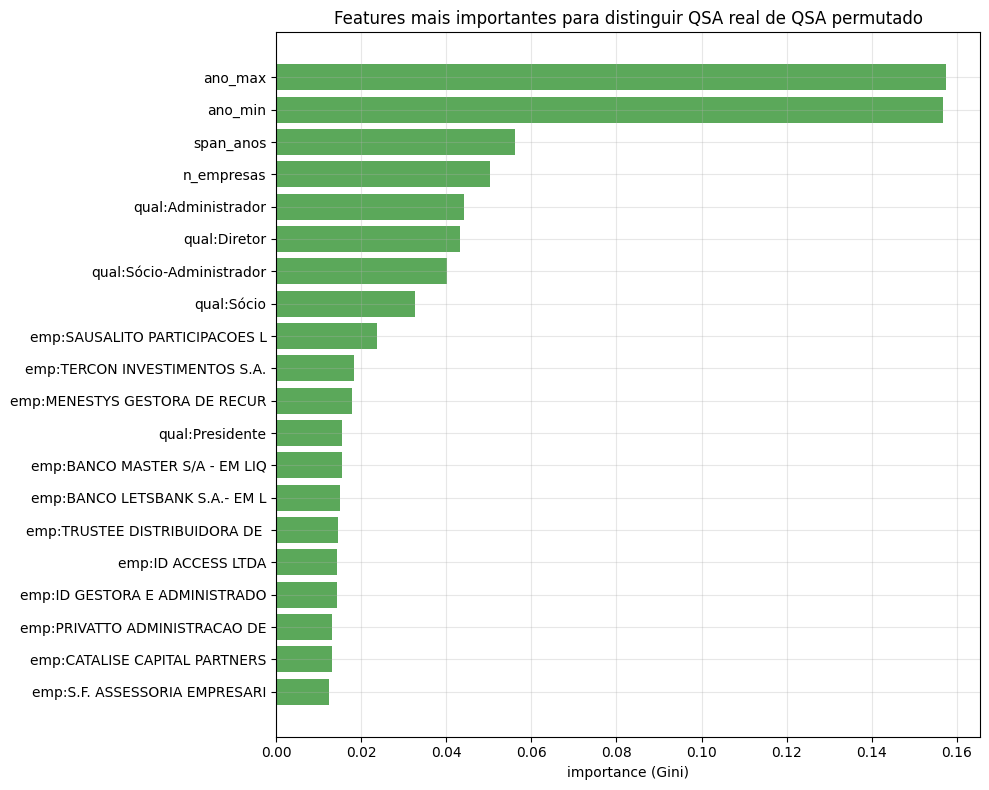

In [20]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_feat = feature_importance.head(20).iloc[::-1]
ax.barh(top_feat['feature'], top_feat['importance'], color='#5BA85A')
ax.set_title('Features mais importantes para distinguir QSA real de QSA permutado')
ax.set_xlabel('importance (Gini)')
plt.tight_layout()
plt.show()

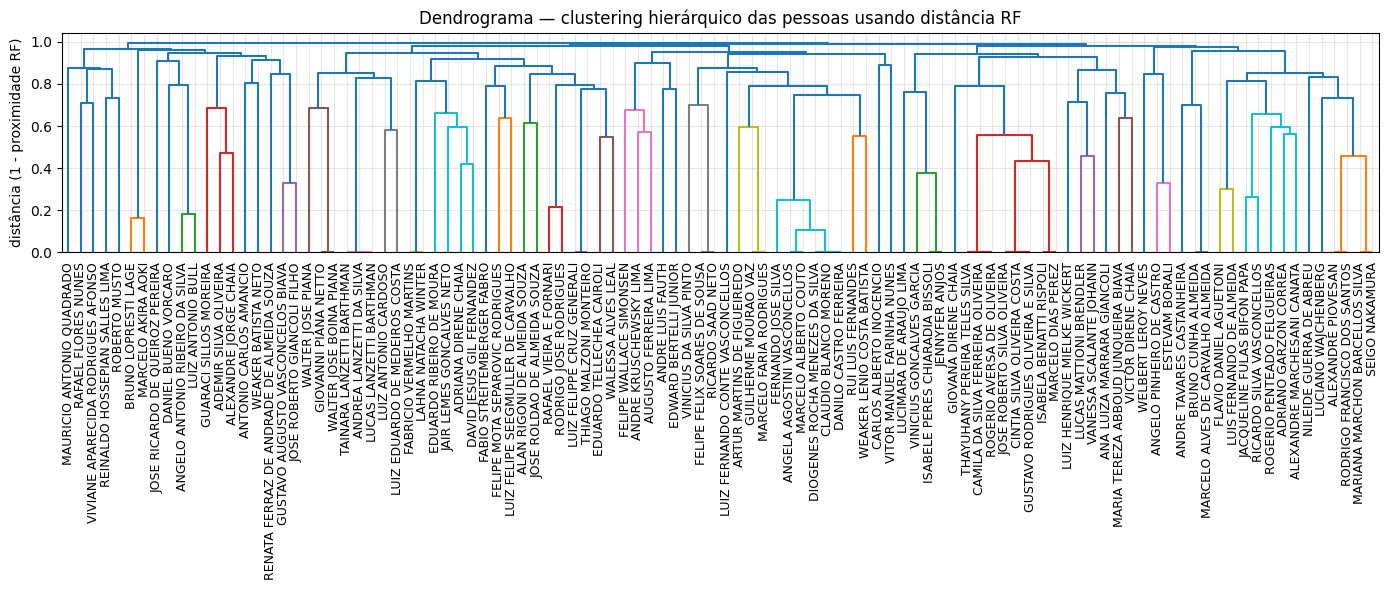

Agrupamento sugerido (corte em distância = 0.7):
  cluster 1: ['RAFAEL FLORES NUNES']
  cluster 2: ['VIVIANE APARECIDA RODRIGUES AFONSO']
  cluster 3: ['REINALDO HOSSEPIAN SALLES LIMA']
  cluster 4: ['ROBERTO MUSTO']
  cluster 5: ['MAURICIO ANTONIO QUADRADO']
  cluster 6: ['BRUNO LOPRESTI LAGE', 'MARCELO AKIRA AOKI']
  cluster 7: ['ANGELO ANTONIO RIBEIRO DA SILVA', 'LUIZ ANTONIO BULL']
  cluster 8: ['DANIEL BUENO VORCARO']
  cluster 9: ['JOSE RICARDO DE QUEIROZ PEREIRA']
  cluster 10: ['ADEMIR SILVA OLIVEIRA', 'ALEXANDRE JORGE CHAIA', 'GUARACI SILLOS MOREIRA']
  cluster 11: ['ANTONIO CARLOS AMANCIO']
  cluster 12: ['WEAKER BATISTA NETO']
  cluster 13: ['GUSTAVO AUGUSTO VASCONCELOS BIAVA', 'JOSE ROBERTO GIANCOLI FILHO']
  cluster 14: ['RENATA FERRAZ DE ANDRADE DE ALMEIDA SOUZA']
  cluster 15: ['GIOVANNI PIANA NETTO', 'WALTER JOSE BOINA PIANA', 'WALTER JOSE PIANA']
  cluster 16: ['ANDREA LANZETTI DA SILVA', 'LUCAS LANZETTI BARTHMAN', 'TAINARA LANZETTI BARTHMAN']
  cluster 17: ['LUIZ ANTO

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

dist_rf = 1 - prox_df.values
np.fill_diagonal(dist_rf, 0)

condensed = []
for i in range(len(nomes)):
    for j in range(i+1, len(nomes)):
        condensed.append(dist_rf[i, j])
condensed = np.array(condensed)

Z = linkage(condensed, method='average')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=nomes, leaf_rotation=90, leaf_font_size=9, ax=ax,
           color_threshold=0.7)
ax.set_title('Dendrograma — clustering hierárquico das pessoas usando distância RF')
ax.set_ylabel('distância (1 - proximidade RF)')
plt.tight_layout()
plt.show()

clusters = fcluster(Z, t=0.7, criterion='distance')
cluster_df = pd.DataFrame({'nome': nomes, 'cluster': clusters}).sort_values(['cluster', 'nome'])
print('Agrupamento sugerido (corte em distância = 0.7):')
for c in sorted(cluster_df['cluster'].unique()):
    membros = cluster_df[cluster_df['cluster'] == c]['nome'].tolist()
    print(f'  cluster {c}: {membros}')

## 7. Conclusões e próximas iterações

### O que este notebook mostrou

1. **Estado do dataset** — 82 empresas, 19 pessoas, 30 participações, 156 papéis CVM, 517 dias de informe diário dos 4 FMP-FGTS.
2. **Concentração de papéis** — Angelo Antonio e Luiz Bull aparecem em 4 entidades cada, mais que o próprio Vorcaro (3). São os "diretores invisíveis" da operação.
3. **Linha do tempo** — as entradas no QSA aceleram drasticamente nos 12 meses antes da liquidação, com 5 marcos densos entre nov/2024 e nov/2025.
4. **Curvas dos FMP-FGTS** — os 2 BANESTES param de reportar em 06/08/2025 (mesmo dia), o MAXIMA Petrobras opera até 12/11/2025, o MAXIMA Vale do Rio Doce nunca aparece em 2025.
5. **RandomForest Proximity** — método não-supervisionado de Breiman aplicado às 19 pessoas com features de incidência empresa + qualificação + janela temporal. Gera matriz de proximidade e clusters hierárquicos. **Pequena amostra exige cautela estatística**, mas a estrutura emerge.

### Limitações honestas

- 19 pessoas é amostra muito pequena para qualquer conclusão estatística robusta.
- RF Proximity assume co-ocorrência como sinal — não captura relações fora do QSA (familiares, profissionais anteriores).
- Snapshot da Receita, não histórico.
- CPFs mascarados — risco de nomes homônimos serem fundidos.

### Próximas iterações sugeridas

- Expandir a coleta diária para os 57 fundos (não só os 4 FMPs).
- Coletar QSA das 9 gestoras parceiras e incorporar ao dataset — vai aumentar N e revelar pontes societárias.
- Cruzar com Portal da Transparência (CEIS / CNEP) — adiciona feature "presença em sanções".
- Consultar CVMWeb manualmente sobre STERN FIP (CNPJ 56823324000184).
- Validar achados com 3 reportagens grandes sobre o caso Master.